In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

In [2]:
GHIBLI = ['tt0087544', 'tt0092067', 'tt0095327', 'tt0096283', 'tt0097814', 'tt0102587', 'tt0104652', 'tt0108432',
          'tt0110008', 'tt0113824', 'tt0119698', 'tt0206013', 'tt0245429', 'tt0347618', 'tt0347149', 'tt0495596',
          'tt0876563', 'tt1568921', 'tt1798188', 'tt2013293', 'tt2576852', 'tt3398268', 'tt12441478', 'tt6587046']

PIXAR = ['tt0114709', 'tt0120623', 'tt0120363', 'tt0198781', 'tt0266543', 'tt0317705', 'tt0317219', 'tt0382932',
         'tt0910970', 'tt1049413', 'tt0435761', 'tt1216475', 'tt1217209', 'tt1453405', 'tt2096673', 'tt1979388',
         'tt2277860', 'tt3606752', 'tt2380307', 'tt3606756', 'tt1979376', 'tt7146812', 'tt2948372', 'tt12801262',
         'tt8097030', 'tt15789038', 'tt22022452']

DREAMWORKS = ['tt0120587', 'tt0120794', 'tt0120630', 'tt0138749', 'tt0264734', 'tt0126029', 'tt0166813', 'tt0165982',
              'tt0298148', 'tt0307453', 'tt0351283', 'tt0312004', 'tt0327084', 'tt0424095', 'tt0413267', 'tt0389790',
              'tt0441773', 'tt0479952', 'tt0892769', 'tt0892782', 'tt0892791', 'tt1001526', 'tt1302011', 'tt0448694',
              'tt1277953', 'tt1446192', 'tt0481499', 'tt1860353', 'tt0864835', 'tt1646971', 'tt1911658', 'tt2224026',
              'tt2267968', 'tt1679335', 'tt3874544', 'tt2091256', 'tt2386490', 'tt6587640', 'tt2850386', 'tt6932874',
              'tt3915174', 'tt6324278', 'tt11084896', 'tt8115900', 'tt27155038', 'tt14362112', 'tt8337264', 'tt10551654',
              'tt21692408', 'tt29623480']

DISNEY = ['tt0116683', 'tt0055254', 'tt0280030', 'tt0079475', 'tt2953050', 'tt0076363', 'tt0109162', 'tt0120762',
          'tt0046183', 'tt0041890', 'tt0220099', 'tt0101414', 'tt11304740', 'tt0076929', 'tt0107688', 'tt1772341',
          'tt0120913', 'tt0095776', 'tt0358082', 'tt2294629', 'tt0306444', 'tt3513500', 'tt0076593', 'tt5848272',
          'tt0212112', 'tt6009292', 'tt1305591', 'tt2980706', 'tt0130623', 'tt0213268', 'tt0116583', 'tt4520988',
          'tt0133240', 'tt0099472', 'tt0405469', 'tt0230011', 'tt0041094', 'tt0382932', 'tt15847828', 'tt0372871',
          'tt0397892', 'tt0039404', 'tt10298840', 'tt0032910', 'tt1067106', 'tt13623880', 'tt0040580', 'tt0114148',
          'tt0328880', 'tt13834480', 'tt0265632', 'tt1691917', 'tt32452718', 'tt0407121', 'tt3521164', 'tt0120917',
          'tt0082406', 'tt0038969', 'tt0057546', 'tt0100477', 'tt0053285', 'tt0275847', 'tt0323642', 'tt0038718',
          'tt0187819', 'tt0212114', 'tt0034091', 'tt0061852', 'tt0398286', 'tt0034492', 'tt0361089', 'tt0091149',
          'tt0396555', 'tt29033964', 'tt0103639', 'tt0070608', 'tt0029583', 'tt0119282', 'tt0076538', 'tt0113198',
          'tt2948356', 'tt0299172', 'tt1217213', 'tt0212116', 'tt0120855', 'tt1185834', 'tt0048280', 'tt0065421',
          'tt0120910', 'tt0229664', 'tt0033563', 'tt0088814', 'tt0118617', 'tt1449283', 'tt0032455', 'tt1142977',
          'tt0371606', 'tt0038166', 'tt0780521', 'tt0097757', 'tt0043274', 'tt0210654', 'tt0250950', 'tt0283426',
          'tt0042332', 'tt0317219', 'tt0036497', 'tt32452564', 'tt0092695', 'tt0239634', 'tt2245084', 'tt5109280',
          'tt0076618', 'tt13622970', 'tt0110357']

In [3]:
PALETA = ["#FEBA17","#14B1D5","#328E6E", "#D91656", "#EB5B00", "#273F4F",]
def set_style(mode='presentacion'):
    """
    Configura estilos de seaborn/matplotlib según el modo:
      - 'presentacion': tipografía grande, fondo beige y rejilla destacada.
      - 'reporte': tipografía más pequeña, fondo blanco y rejilla suave.
    """
    if mode == 'presentacion':
        context = "talk"
        rc = {
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans"],
            "font.size": 12,
            # titulo
            "figure.titlesize": 30,
            "figure.titleweight": "bold",
            # ejes
            "axes.titlesize": 24,
            "xtick.labelsize": 22,
            "ytick.labelsize": 22,
            "axes.titlepad": 10,
            "axes.facecolor": "#F5F5DC",
            "axes.spines.right": False,
            "axes.spines.top": False,
            "axes.edgecolor": "#333333",
            "axes.grid": True,
            # ejes rejilla
            "grid.color": "#222",
            "grid.linestyle": "--",
            "grid.linewidth": 1.5,
            "grid.alpha": 0.5,
            # ejes etiquetas
            "axes.labelsize": 26,
            # pad entre eje y etiquetas de valores
            "xtick.major.pad": 15,
            "ytick.major.pad": 15,
            # pad entre el nombre del eje y los ticks
            "axes.labelpad": 20,
            # leyenda
            "legend.fontsize": 18,
            "legend.title_fontsize": 20,
            "legend.labelspacing": 1.5,
            "legend.handlelength": 2,
            "legend.handleheight": 0.5,
            "legend.borderpad": 0.5,
            "legend.borderaxespad": 0.5,
            "legend.markerscale": 1.5,
            "legend.framealpha": 0.8,
            "legend.loc": "best",
            "legend.facecolor": "#F5F5DC",
            "legend.shadow": True,
            "legend.edgecolor": "#333333",
            "legend.frameon": True,
            # fondo
            "figure.facecolor": "#F5F5DC",
            # figura resolucion y tamaño
            "figure.dpi": 250,
            "figure.figsize": (12, 8)
            }
    elif mode == 'reporte':
        context = "notebook"
        rc = {
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans"],
            "font.size": 12,
            # titulo
            "figure.titlesize": 25,
            "figure.titleweight": "bold",
            # ejes
            "axes.titlesize": 22,
            "xtick.labelsize": 18,
            "ytick.labelsize": 18,
            "axes.titlepad": 14,
            "axes.facecolor": "#F5F5DC",
            "axes.spines.right": False,
            "axes.spines.top": False,
            "axes.edgecolor": "#333333",
            "axes.grid": True,
            # ejes rejilla
            "grid.color": "#222",
            "grid.linestyle": "--",
            "grid.linewidth": 1.5,
            "grid.alpha": 0.5,
            # ejes etiquetas
            "axes.labelsize": 22,
            # pad entre eje y etiquetas de valores
            "xtick.major.pad": 15,
            "ytick.major.pad": 15,
            # pad entre el nombre del eje y los ticks
            "axes.labelpad": 15,
            # leyenda
            "legend.fontsize": 14,
            "legend.title_fontsize": 16,
            "legend.labelspacing": 1.5,
            "legend.handlelength": 2,
            "legend.handleheight": 0.5,
            "legend.borderpad": 0.5,
            "legend.borderaxespad": 0.5,
            "legend.markerscale": 1.5,
            "legend.framealpha": 0.8,
            "legend.loc": "best",
            "legend.facecolor": "#F5F5DC",
            "legend.shadow": True,
            "legend.edgecolor": "#333333",
            "legend.frameon": True,
            # fondo
            "figure.facecolor": "#F5F5DC",
            # figura resolucion y tamaño
            "figure.dpi": 180,
            "figure.figsize": (12, 8)
            }
    else:
        raise ValueError("Modo desconocido. Use 'presentacion' o 'reporte'.")
    sns.set_theme(context=context, palette=PALETA, rc=rc)
    plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETA)

# Ejemplo de uso:
set_style('presentacion')
# set_style('reporte')

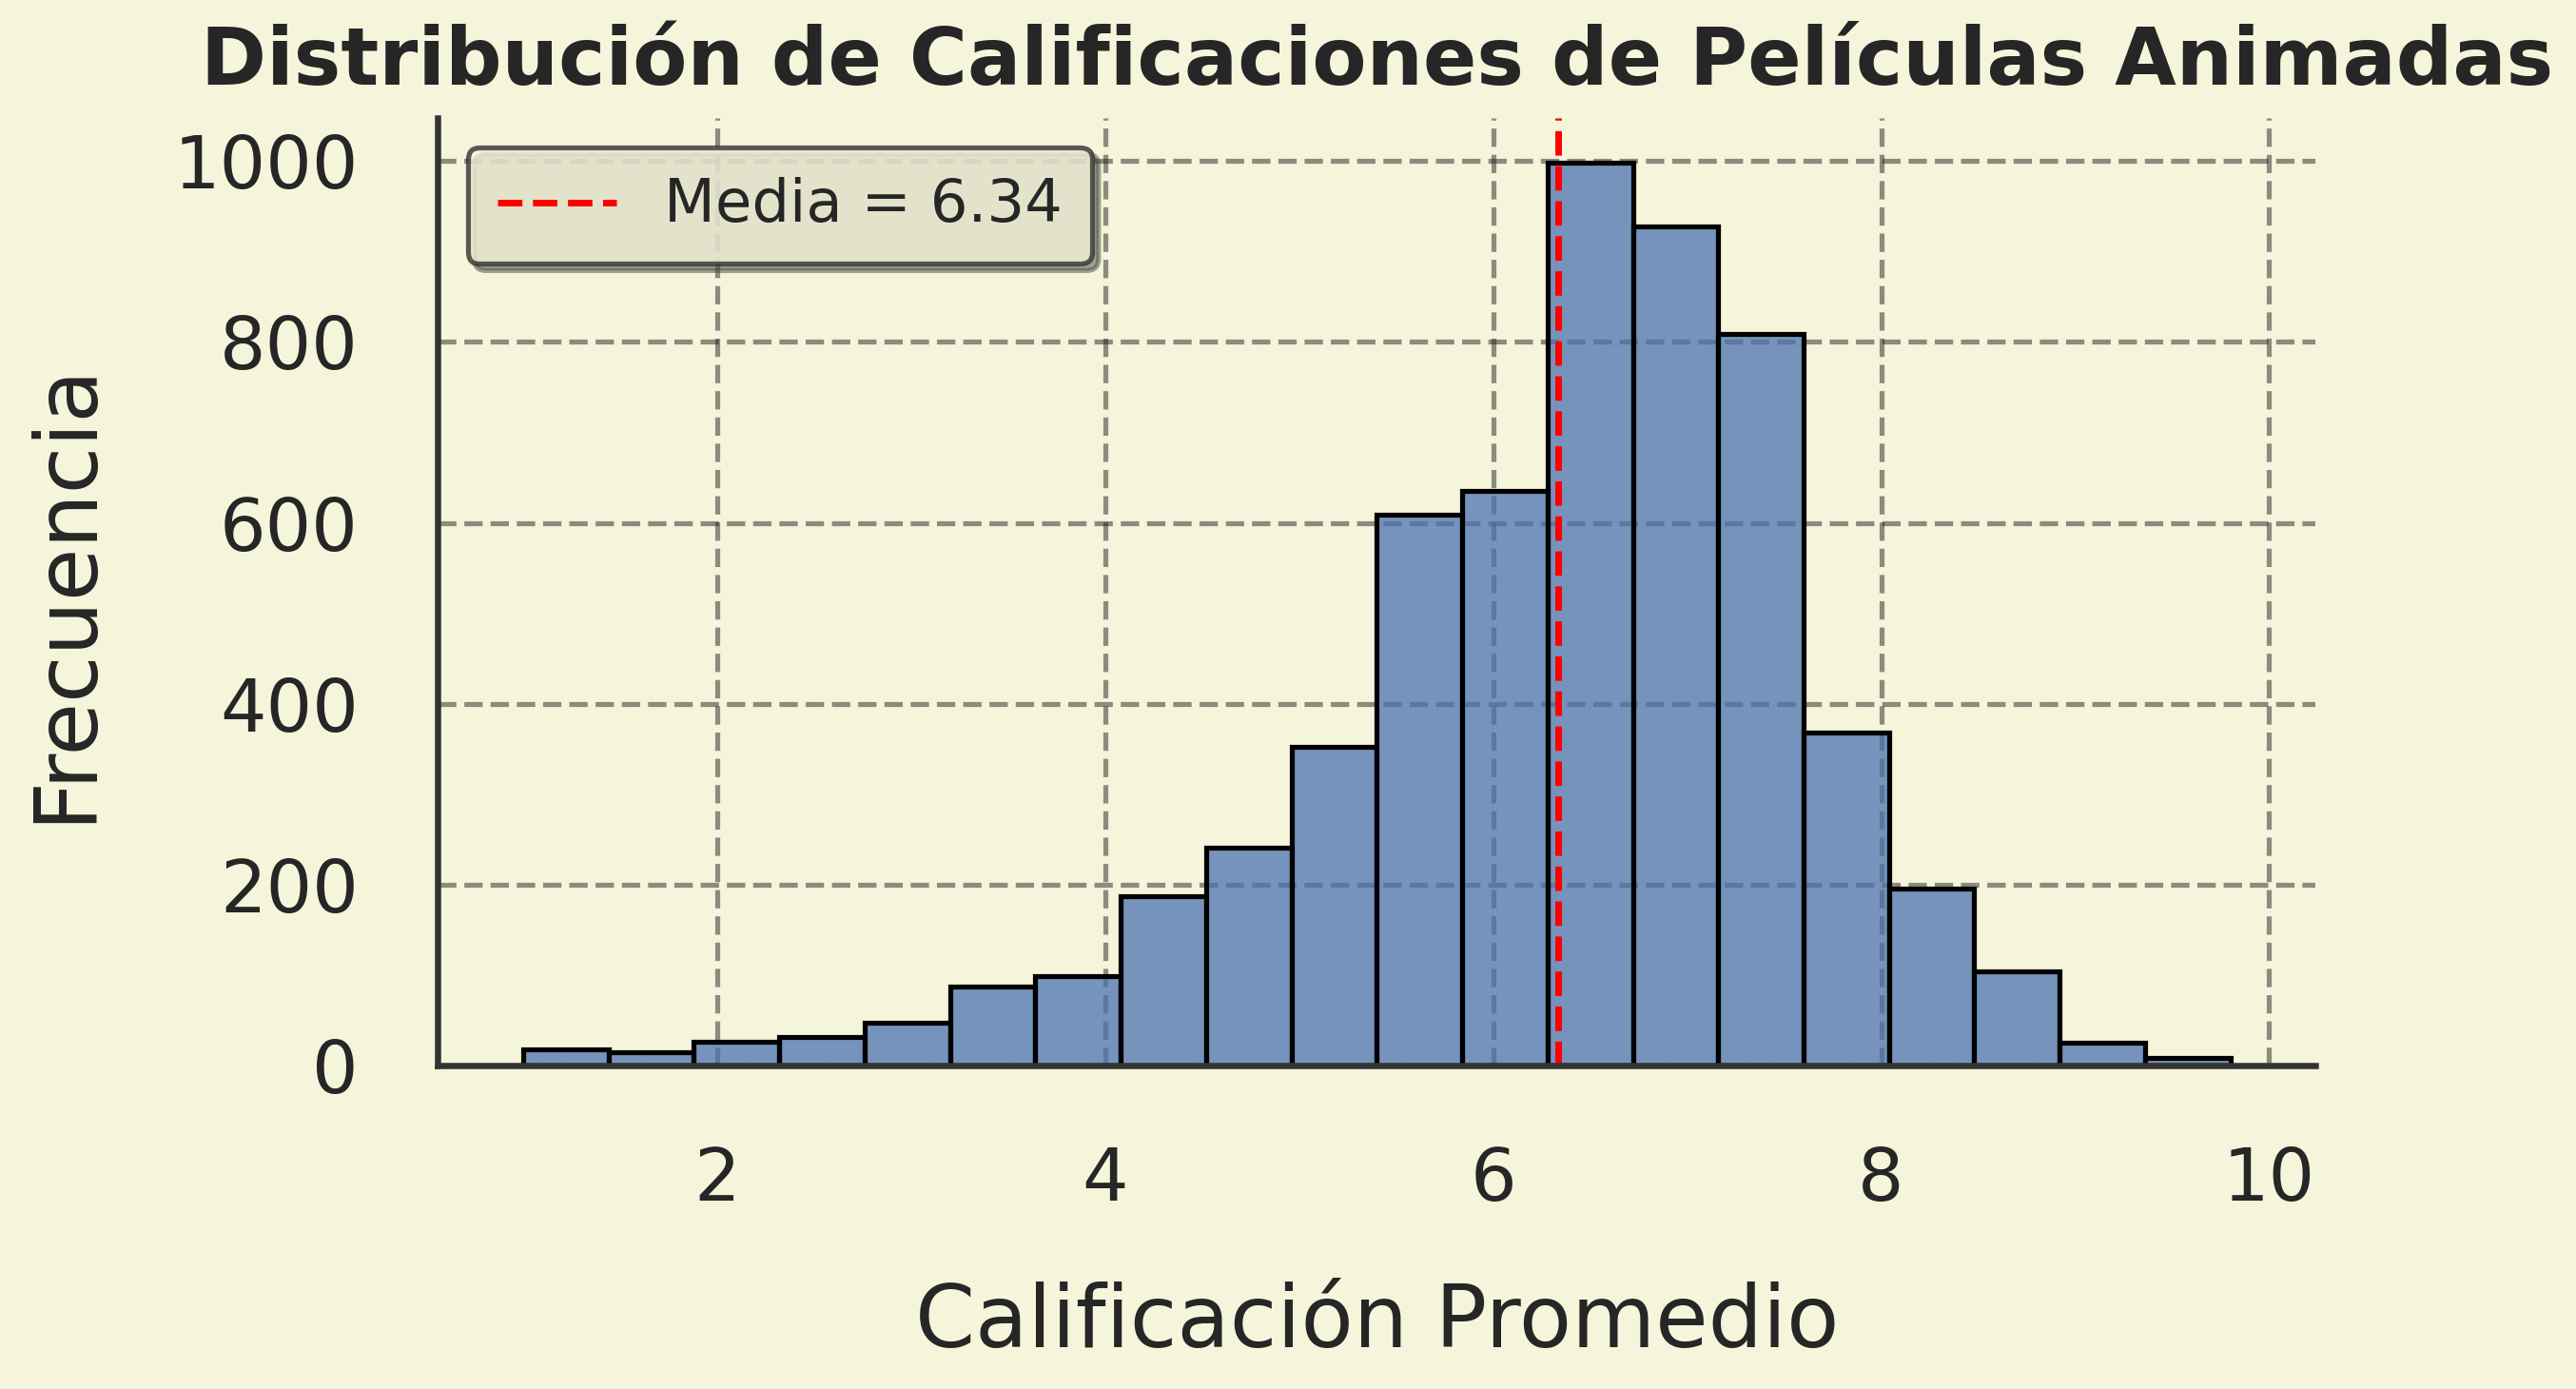

In [4]:
# Conexión a la base de datos
conn = sqlite3.connect("im.db")

# Leer las calificaciones promedio
query = "SELECT averageRating FROM titles WHERE averageRating IS NOT NULL"
ratings_df = pd.read_sql_query(query, conn)
conn.close()

mean_rating = ratings_df['averageRating'].mean()

# Gráfica
plt.figure(figsize=(10, 6))
sns.histplot(ratings_df['averageRating'], bins=20, kde=False, color="#4C72B0", edgecolor="black")

# Línea de media
plt.axvline(mean_rating, color='red', linestyle='--', linewidth=2, label=f"Media = {mean_rating:.2f}")

# Títulos y etiquetas
plt.title("Distribución de Calificaciones de Películas Animadas", fontweight='bold')
plt.xlabel("Calificación Promedio")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()


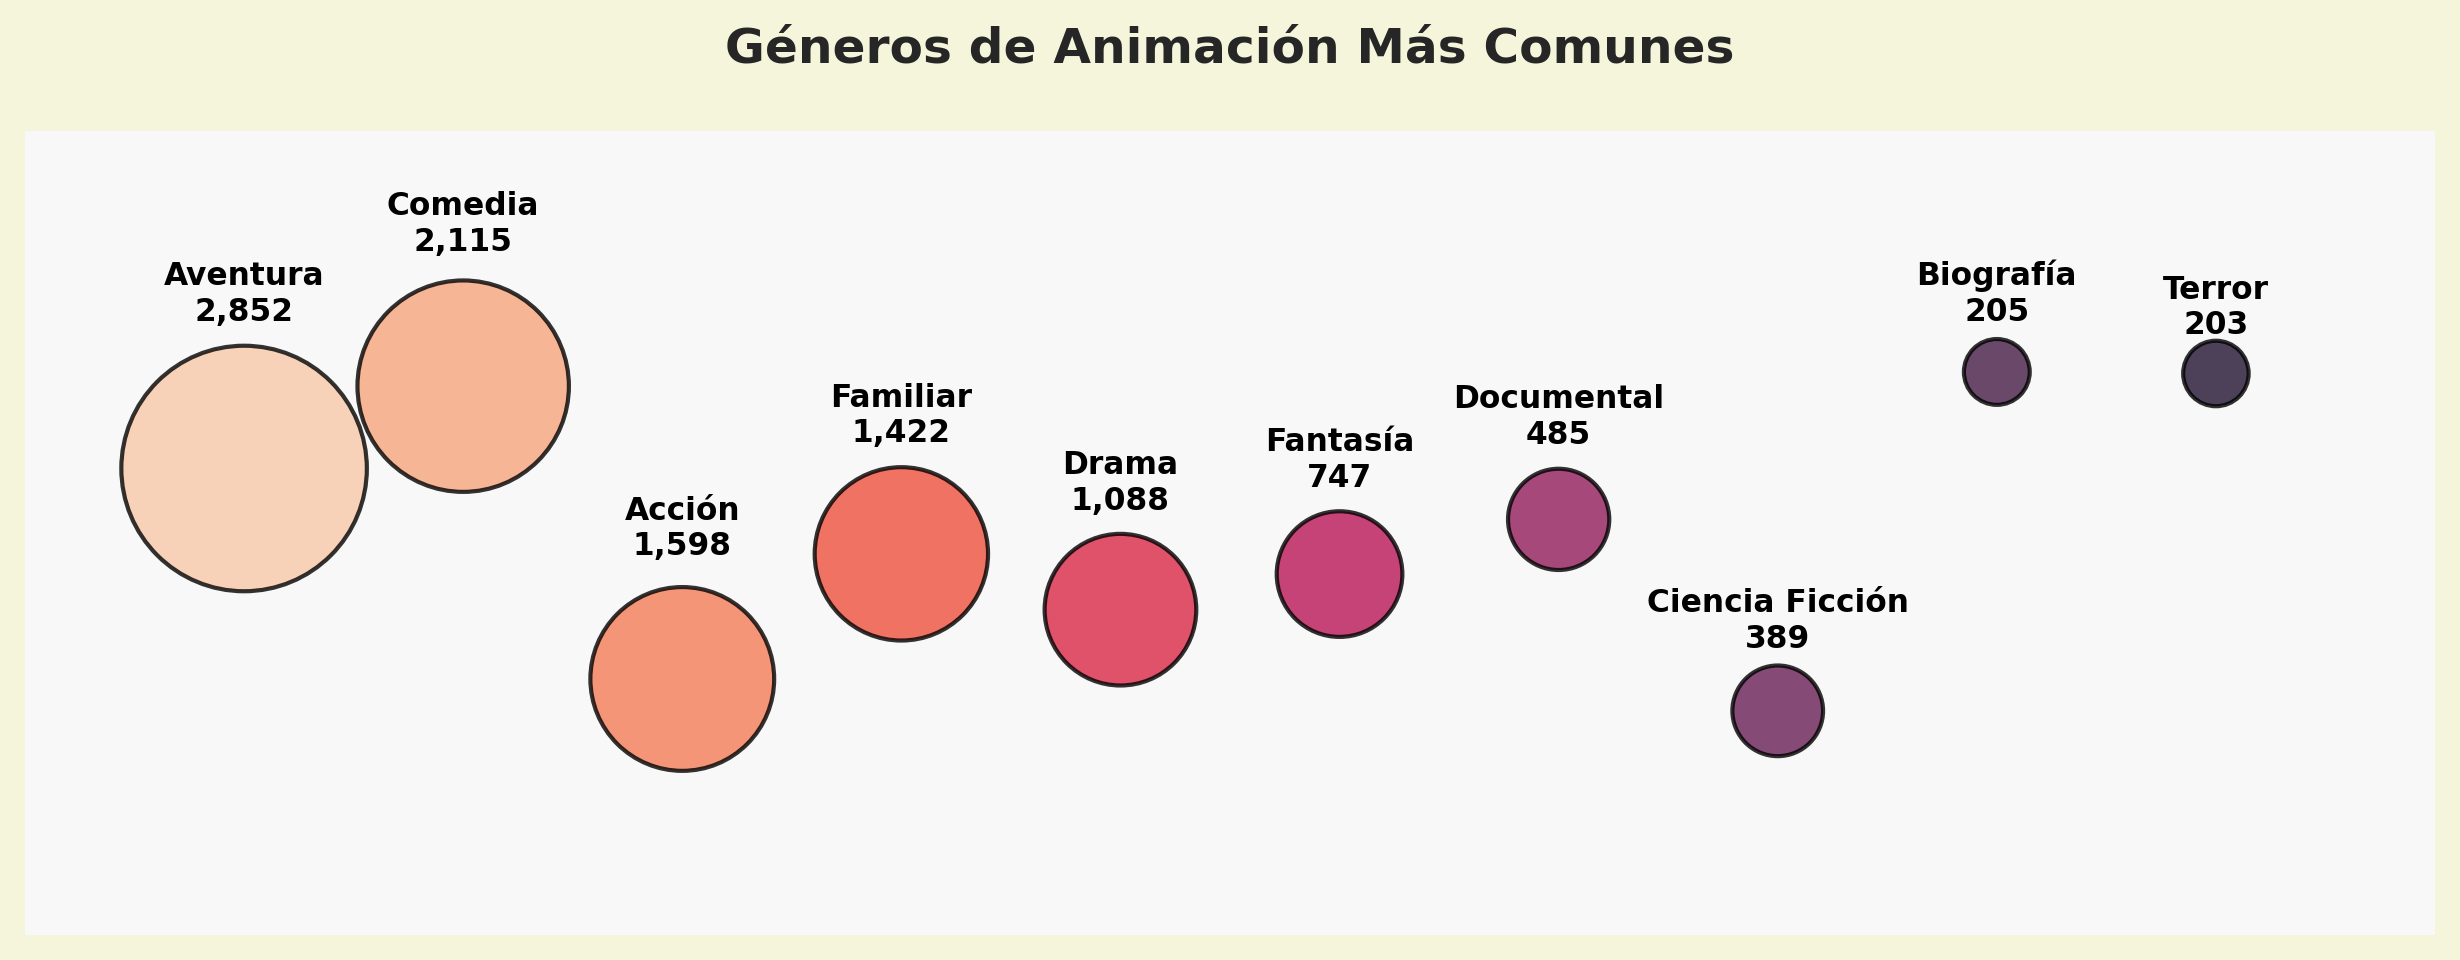

In [5]:
# Conectar a la base de datos
conn = sqlite3.connect("im.db")

# Consulta para contar títulos por género
query = """
SELECT g.genre_name, COUNT(*) AS total
FROM title_genres tg
JOIN genres g ON g.id = tg.genre_id
GROUP BY g.genre_name
ORDER BY total DESC
LIMIT 10;
"""
genre_df = pd.read_sql_query(query, conn)
conn.close()

# Diccionario de traducción de géneros
genre_translation = {
    "Adventure": "Aventura",
    "Comedy": "Comedia",
    "Action": "Acción",
    "Family": "Familiar",
    "Drama": "Drama",
    "Fantasy": "Fantasía",
    "Documentary": "Documental",
    "Sci-Fi": "Ciencia Ficción",
    "Biography": "Biografía",
    "Horror": "Terror"
}

# Aplicar la traducción a la columna
genre_df["genre_name"] = genre_df["genre_name"].map(genre_translation)

# Paleta de colores cálida y progresiva
colors = sns.color_palette("rocket_r", len(genre_df))

# Crear figura
plt.figure(figsize=(10, 4))

# Eje X: cada burbuja para un género (categorías)
x = np.arange(len(genre_df))
y = np.random.uniform(0.5, 1.5, size=len(genre_df))  # altura aleatoria para estética

# Escalar los tamaños proporcionalmente al total
sizes = genre_df["total"] / genre_df["total"].max() * 5000

# Dibujar las burbujas
scatter = plt.scatter(
    x, y,
    s=sizes,
    c=colors,
    alpha=0.8,
    edgecolors="black",
    linewidth=1.2
)

# Etiquetas encima de cada burbuja
delta = 0.35  # Desplazamiento para evitar superposición
for i, (genre, total) in enumerate(zip(genre_df["genre_name"], genre_df["total"])):
    plt.text(
        x[i], y[i] + delta,
        f"{genre}\n{total:,}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='black'
    )
    delta -= 0.03  # Aumentar el desplazamiento para la siguiente etiqueta

# Estética general
plt.xticks([])  # Ocultar ticks del eje X
plt.yticks([])  # Ocultar eje Y
plt.xlim(-1, len(genre_df))
plt.ylim(0, 2)

plt.title("Géneros de Animación Más Comunes", fontsize=14, pad=20, fontweight='bold')
plt.gca().set_facecolor("#F8F8F8")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

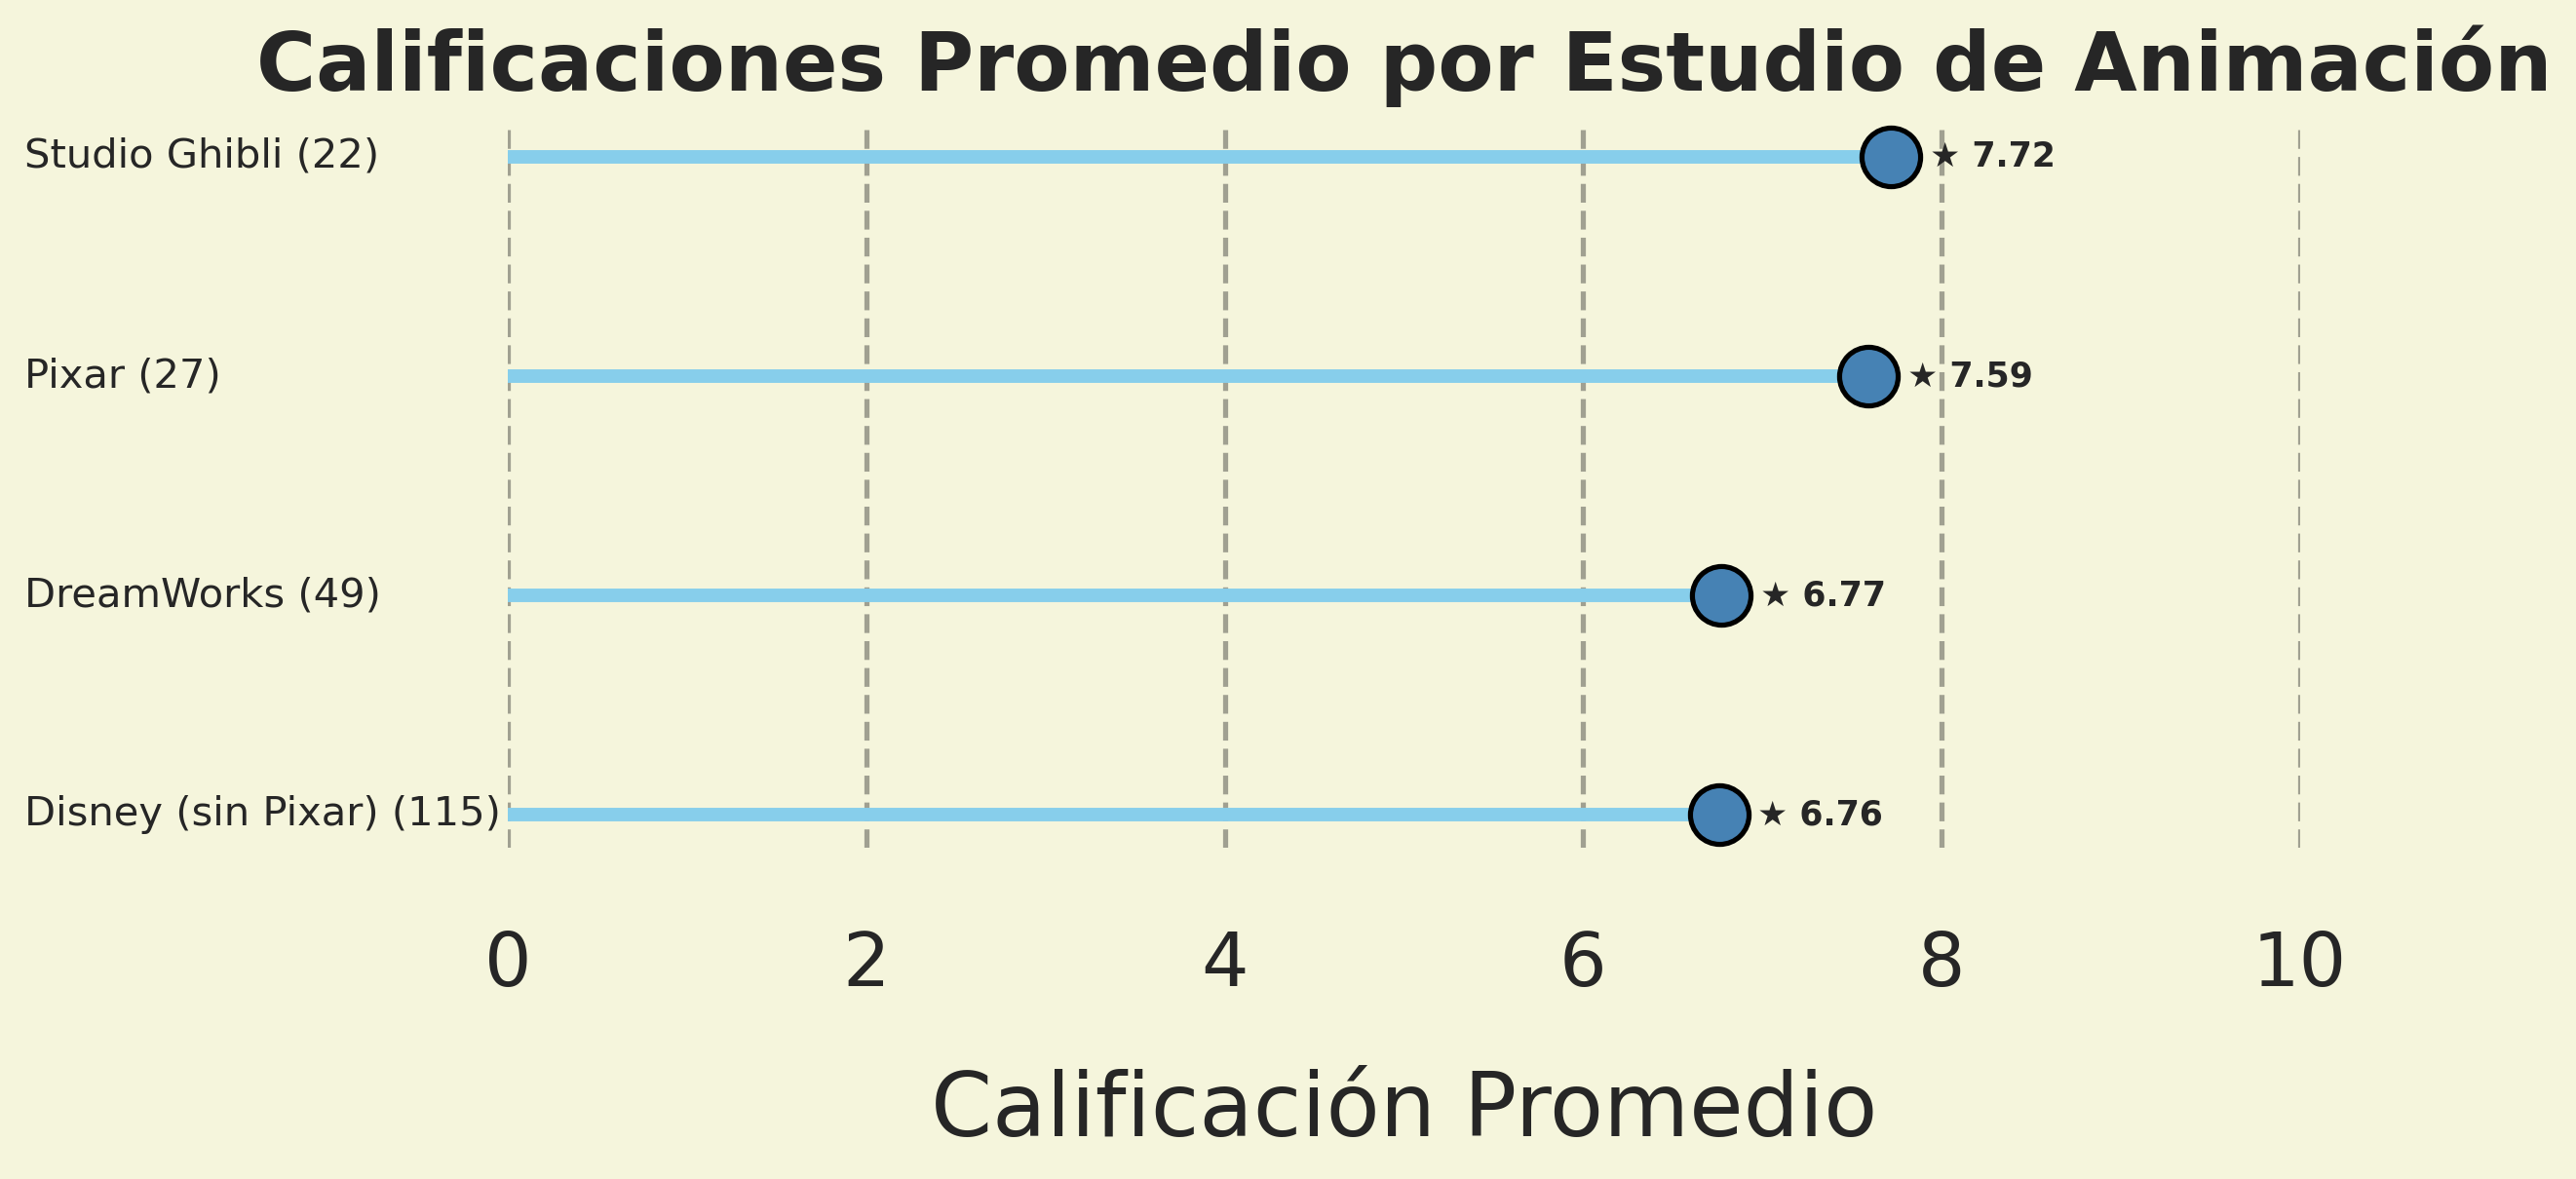

In [6]:
# Conectar a la base de datos
conn = sqlite3.connect("im.db")

# Diccionario con las listas de tconsts por compañía
companies = {
    "Studio Ghibli": GHIBLI,
    "Disney": DISNEY,
    "Pixar": PIXAR,
    "DreamWorks": DREAMWORKS
}

# Lista para almacenar los resultados
company_ratings = []

# Consultar promedio y cantidad por compañía
for name, id_list in companies.items():
    placeholders = ",".join("?" for _ in id_list)
    query = f"""
        SELECT AVG(averageRating), COUNT(*) 
        FROM titles
        WHERE tconst IN ({placeholders})
    """
    avg, count = conn.execute(query, id_list).fetchone()
    company_ratings.append((name, avg, count))

conn.close()

# Crear DataFrame
ratings_df = pd.DataFrame(company_ratings, columns=["Compañía", "Promedio", "Películas"])

# Renombrar etiquetas de compañías para visualización
label_mapping = {
    "Disney": "Disney (sin Pixar)"
}
ratings_df["Compañía"] = ratings_df["Compañía"].replace(label_mapping)

# Ordenar por promedio
ratings_df = ratings_df.sort_values(by="Promedio", ascending=True).reset_index(drop=True)

# Gráfica
plt.figure(figsize=(10, 5))
y = np.arange(len(ratings_df))

# Líneas y puntos
plt.hlines(y, 0, ratings_df["Promedio"], color="skyblue", linewidth=4)
plt.scatter(ratings_df["Promedio"], y, s=300, color="steelblue", edgecolors="black", zorder=3)

# Mostrar nombre, promedio y cantidad
for i, (prom, comp, num) in enumerate(zip(ratings_df["Promedio"], ratings_df["Compañía"], ratings_df["Películas"])):
    plt.text(prom + 0.15, i, f" ★ {prom:.2f}", va="center", fontsize=10, fontweight='bold')
    plt.text(-2.7, i, f"{comp} ({num})", va="center", fontsize=12, fontweight='medium')  # ← Aquí agregamos el conteo

# Estética
plt.yticks([])
plt.xlabel("Calificación Promedio")
plt.title("Calificaciones Promedio por Estudio de Animación", fontweight='bold')
plt.xlim(0, 10)
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

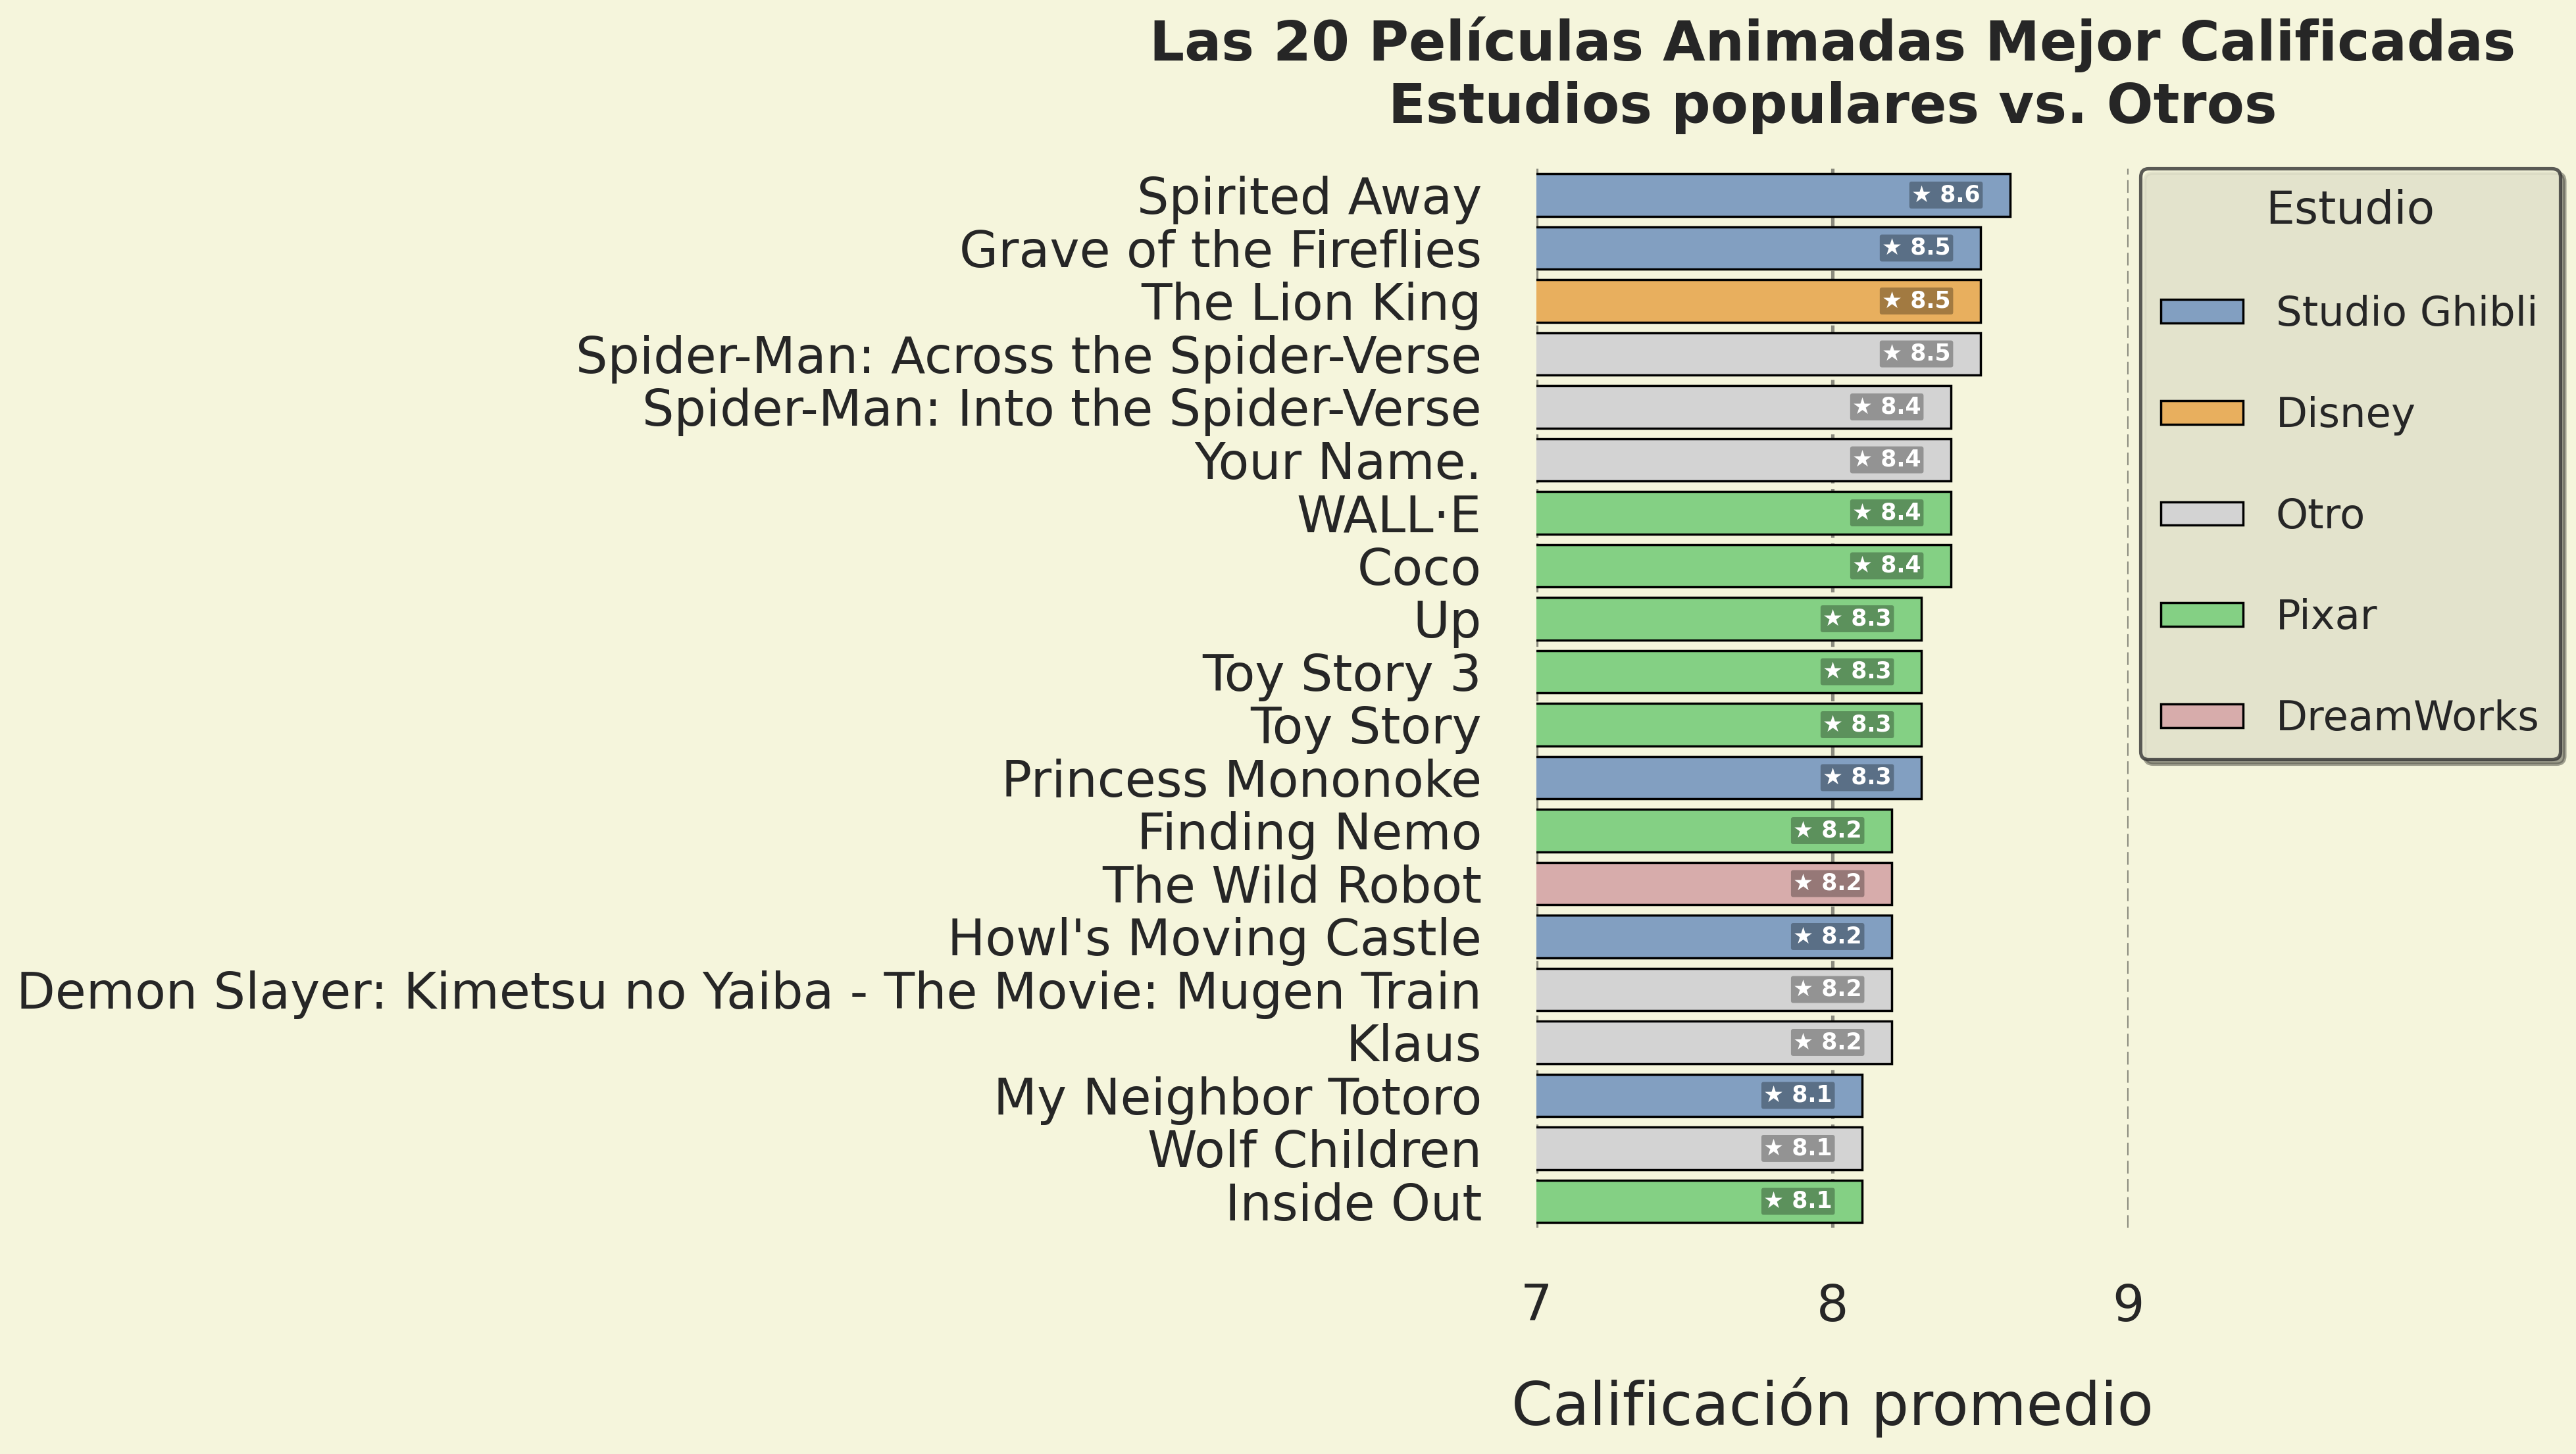

In [7]:
# Crear un DataFrame con los tconst y estudio
def create_company_df(ids, name):
    return pd.DataFrame({"tconst": ids, "studio": name})

all_companies = pd.concat([
    create_company_df(DISNEY, "Disney"),
    create_company_df(PIXAR, "Pixar"),
    create_company_df(DREAMWORKS, "DreamWorks"),
    create_company_df(GHIBLI, "Studio Ghibli")
])

# Conectar a la base de datos
conn = sqlite3.connect("im.db")

# Cargar todos los títulos animados con su rating
query = """
SELECT tconst, primaryTitle, averageRating
FROM titles
WHERE averageRating IS NOT NULL AND numVotes > 50000
"""
title_info = pd.read_sql_query(query, conn)
conn.close()

# Función para asignar estudio
def asignar_estudio(tconst):
    if tconst in DISNEY:
        return "Disney"
    elif tconst in PIXAR:
        return "Pixar"
    elif tconst in DREAMWORKS:
        return "DreamWorks"
    elif tconst in GHIBLI:
        return "Studio Ghibli"
    else:
        return "Otro"

# Asignar estudio
title_info["studio"] = title_info["tconst"].apply(asignar_estudio)

# Top 20 por calificación
top20 = title_info.sort_values("averageRating", ascending=False).head(20)

# Crear la figura
plt.figure(figsize=(16, 9))

# Colores personalizados
palette = {
    "Disney": "#FFB347",
    "Pixar": "#77DD77",
    "DreamWorks": "#DEA5A4",
    "Studio Ghibli": "#779ECB",
    "Otro": "#D3D3D3"
}

# Gráfico de barras horizontales
ax = sns.barplot(
    data=top20,
    x="averageRating",
    y="primaryTitle",
    hue="studio",
    dodge=False,
    palette=palette,
    edgecolor="black",
    linewidth=1
)

# Título y ejes
plt.title("Las 20 Películas Animadas Mejor Calificadas\nEstudios populares vs. Otros", pad=20, fontweight='bold')
plt.xlabel("Calificación promedio")
plt.ylabel("")
plt.xlim(7, 9)

# Leyenda fuera
plt.legend(title="Estudio", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)

# Etiquetas en barras
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(
        row["averageRating"] - 0.1,
        i,
        f'★ {row["averageRating"]:.1f}',
        va='center',
        ha='right',
        color='white',
        fontweight='bold',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.1", edgecolor="none", facecolor="black", alpha=0.3)
    )

# Limpiar ejes
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


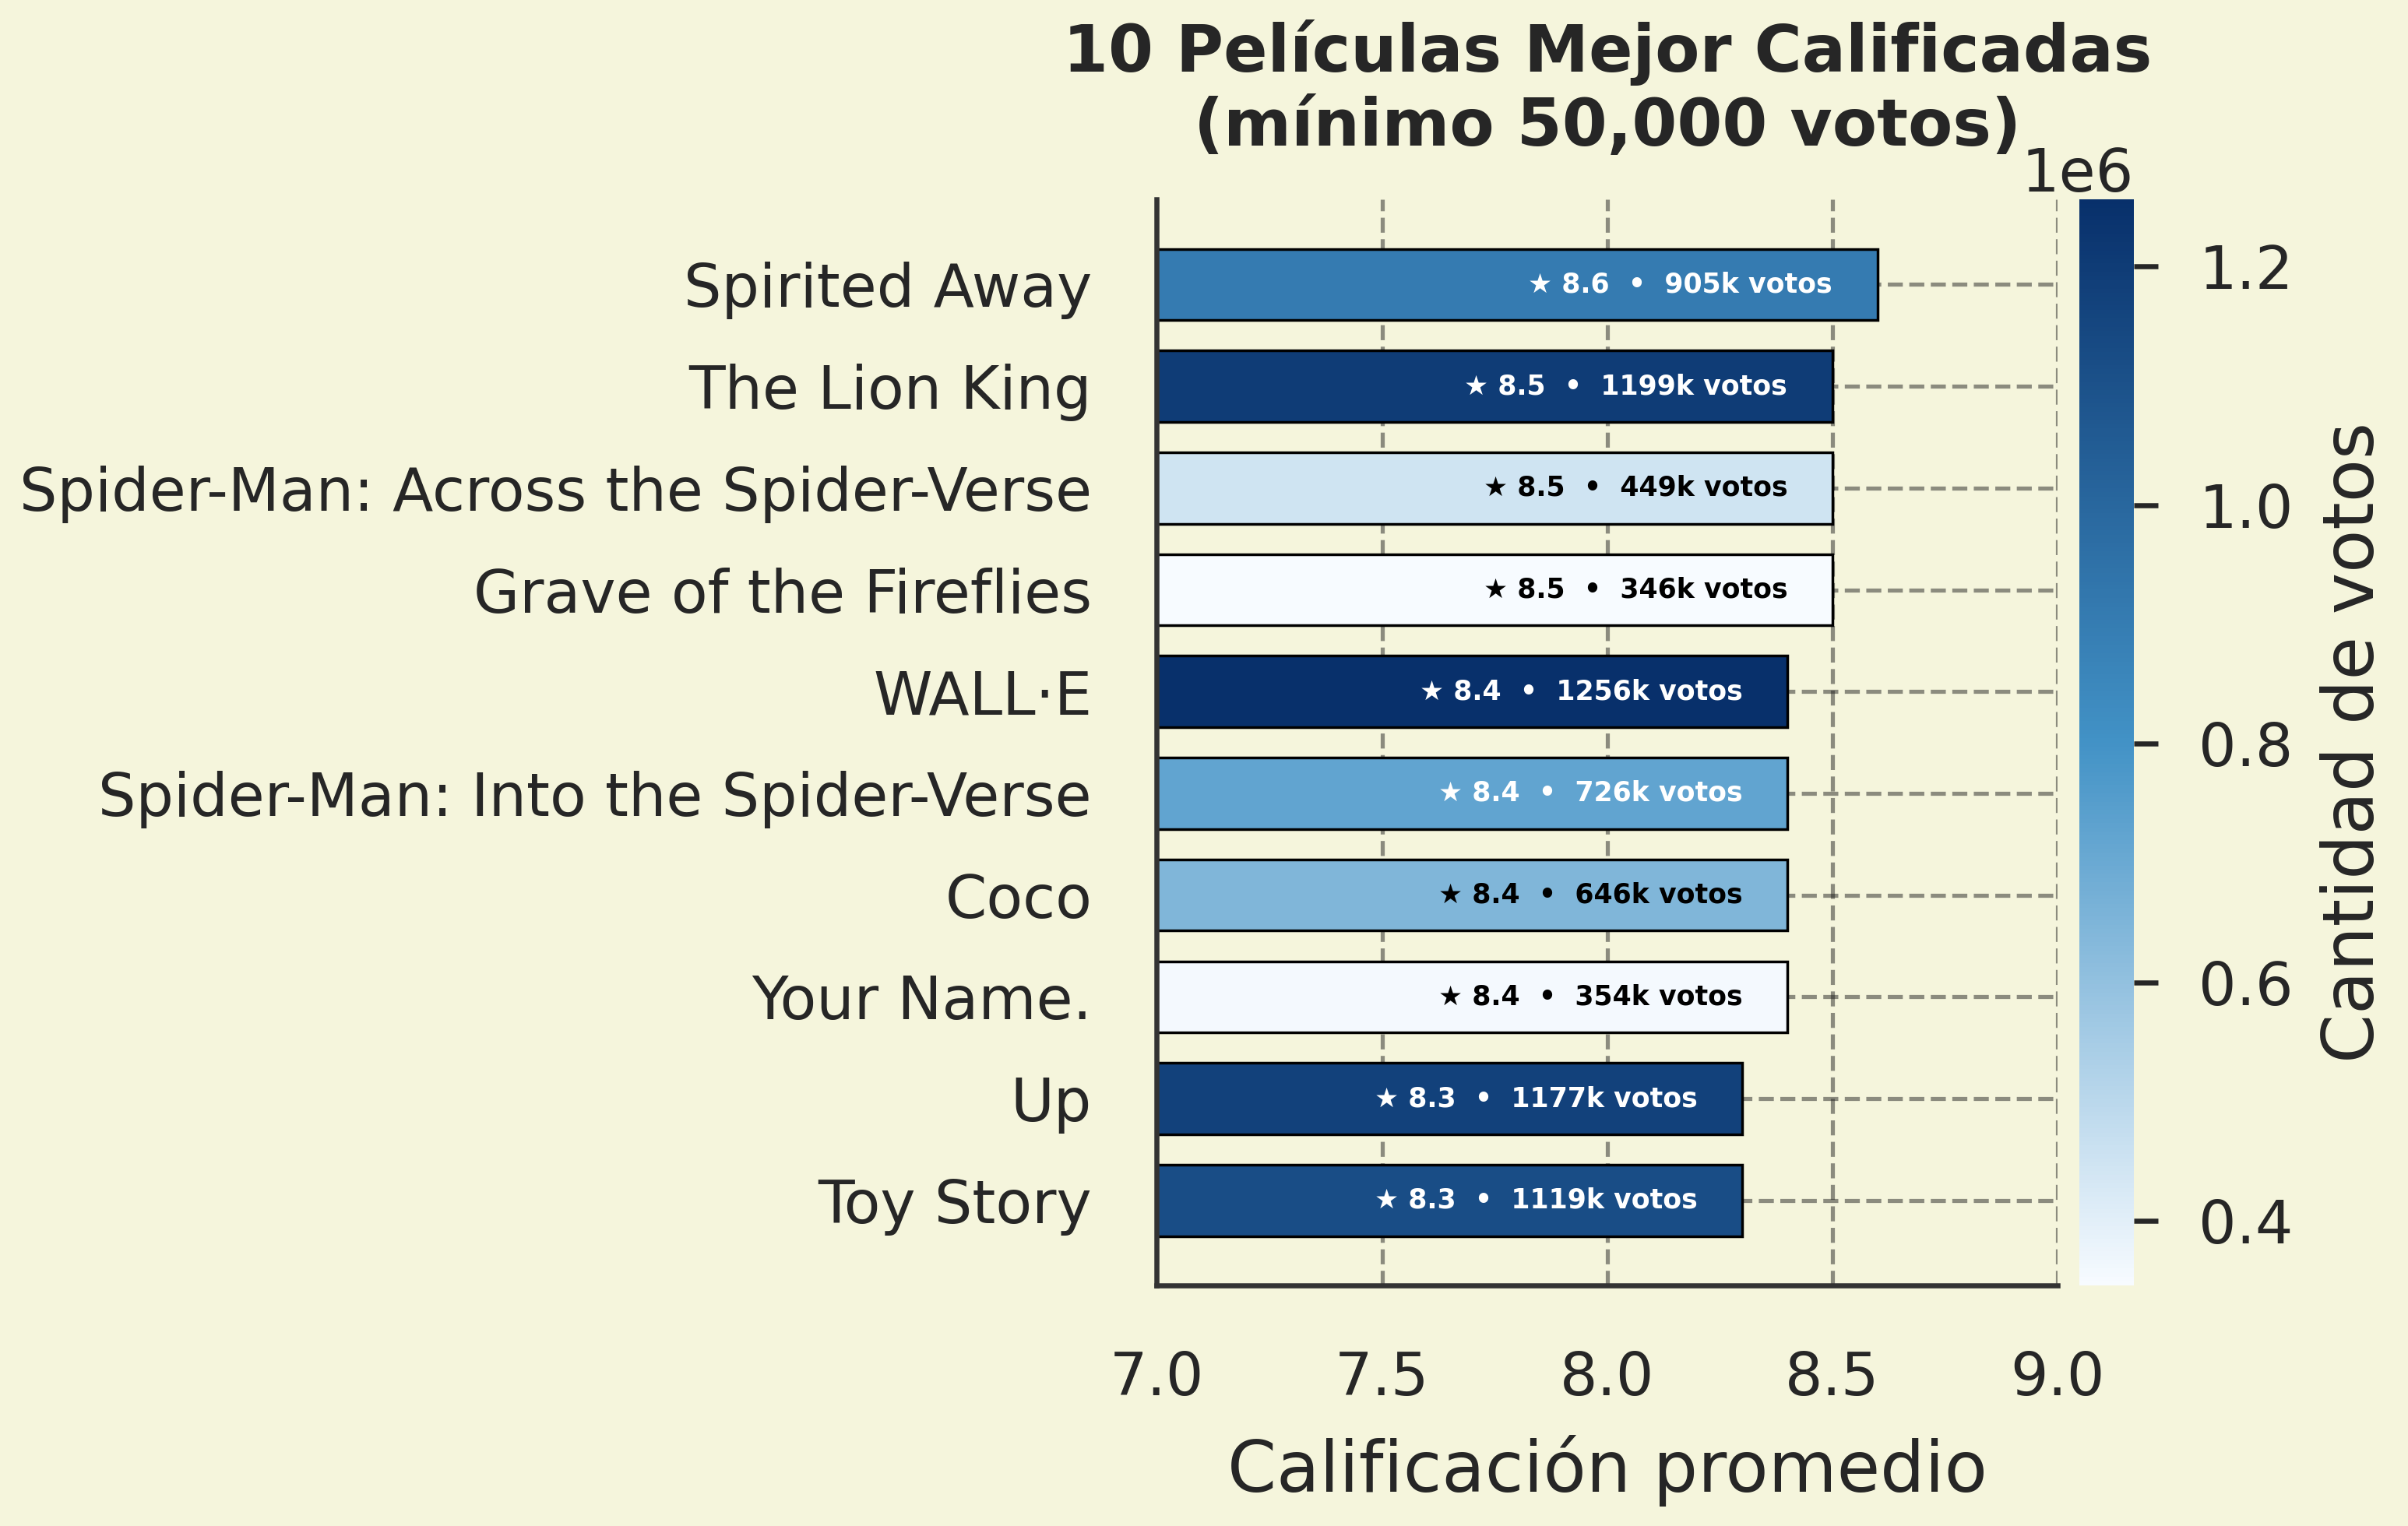

In [8]:
# Conectar a la base de datos
conn = sqlite3.connect("im.db")

# Consulta
query = """
SELECT primaryTitle, averageRating, numVotes
FROM titles
WHERE averageRating IS NOT NULL AND numVotes > 50000
ORDER BY averageRating DESC, numVotes DESC
LIMIT 10
"""

top10_df = pd.read_sql_query(query, conn)
top10_df = top10_df.iloc[::-1].reset_index(drop=True)
conn.close()


# Crear paleta secuencial personalizada
colors = ["#f7fbff", "#4292c6", "#08306b"]  # Azul claro a oscuro
cmap = LinearSegmentedColormap.from_list("custom_blues", colors)
norm = plt.Normalize(top10_df["numVotes"].min(), top10_df["numVotes"].max())

# Configuración de la figura
plt.figure(figsize=(12, 8))
ax = plt.gca()

# Crear barras horizontales
bars = ax.barh(
    top10_df["primaryTitle"],
    top10_df["averageRating"],
    color=cmap(norm(top10_df["numVotes"])),
    height=0.7,
    edgecolor="black",
    linewidth=1
)
# Personalización del gráfico
plt.title("10 Películas Mejor Calificadas\n(mínimo 50,000 votos)", 
          pad=20, fontweight='bold')
plt.xlabel("Calificación promedio", labelpad=10)
plt.ylabel("")
plt.xlim(7, 9)
plt.xticks(np.arange(7, 9.1, 0.5))

# Añadir etiquetas inteligentes
for bar, (_, row) in zip(bars, top10_df.iterrows()):
    # Determinar color de texto basado en luminosidad del fondo
    bar_color = bar.get_facecolor()
    luminance = 0.299 * bar_color[0] + 0.587 * bar_color[1] + 0.114 * bar_color[2]
    text_color = 'black' if luminance > 0.6 else 'white'
    
    # Texto con rating y votos
    ax.text(
        row["averageRating"] - 0.1,
        bar.get_y() + bar.get_height()/2,
        f'★ {row["averageRating"]:.1f}  •  {row["numVotes"]/1000:.0f}k votos',
        ha='right', 
        va='center',
        color=text_color,
        fontweight='bold',
        fontsize=10
    )

# Añadir barra de color
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Cantidad de votos', labelpad=10)
cbar.outline.set_visible(False)

# Layout final
plt.tight_layout()
plt.show()

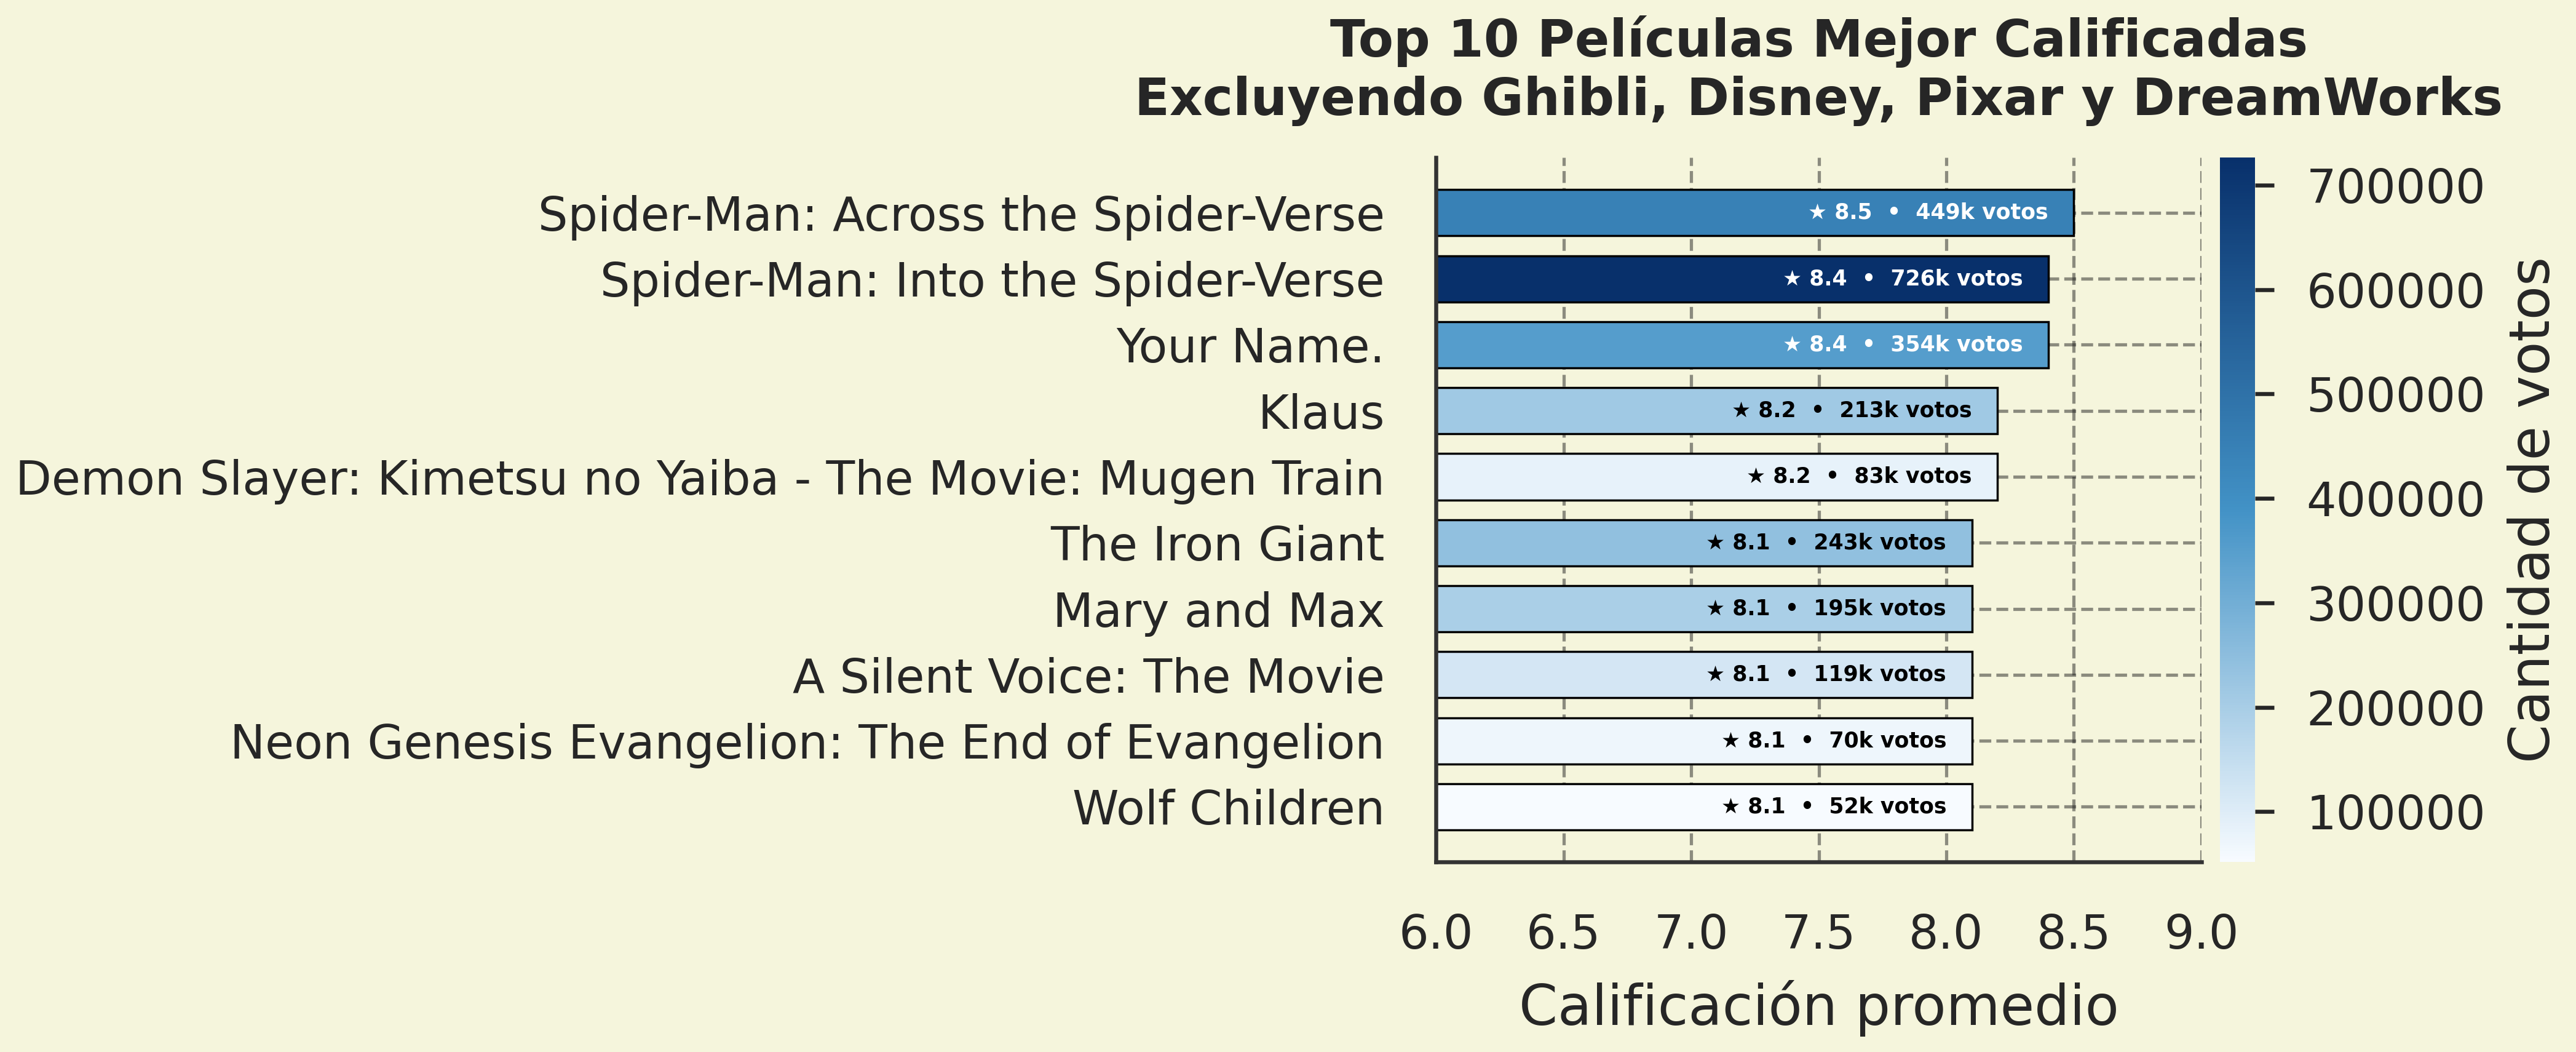

In [9]:
# Unir todas las películas de los estudios en una sola lista
excluded_ttids = GHIBLI + DISNEY + PIXAR + DREAMWORKS

# Conectar a la base de datos
conn = sqlite3.connect("im.db")

# Crear placeholders dinámicos
placeholders = ",".join("?" for _ in excluded_ttids)

# Consulta con exclusión
query = f"""
SELECT primaryTitle, averageRating, numVotes
FROM titles
WHERE averageRating IS NOT NULL
  AND numVotes > 50000
  AND tconst NOT IN ({placeholders})
ORDER BY averageRating DESC, numVotes DESC
LIMIT 10
"""

# Ejecutar consulta
top10_df = pd.read_sql_query(query, conn, params=excluded_ttids)
top10_df = top10_df.iloc[::-1].reset_index(drop=True)
conn.close()

# Paleta personalizada
colors = ["#f7fbff", "#4292c6", "#08306b"]
cmap = LinearSegmentedColormap.from_list("custom_blues", colors)
norm = plt.Normalize(top10_df["numVotes"].min(), top10_df["numVotes"].max())

plt.figure(figsize=(16, 7))
ax = plt.gca()

bars = ax.barh(
    top10_df["primaryTitle"],
    top10_df["averageRating"],
    color=cmap(norm(top10_df["numVotes"])),
    height=0.7,
    edgecolor="black",
    linewidth=1
)

plt.title("Top 10 Películas Mejor Calificadas\nExcluyendo Ghibli, Disney, Pixar y DreamWorks",
          pad=20, fontweight='bold')
plt.xlabel("Calificación promedio", labelpad=10)
plt.ylabel("")
plt.xlim(7, 9)
plt.xticks(np.arange(6, 9.1, 0.5))

# Añadir etiquetas
for bar, (_, row) in zip(bars, top10_df.iterrows()):
    bar_color = bar.get_facecolor()
    luminance = 0.299 * bar_color[0] + 0.587 * bar_color[1] + 0.114 * bar_color[2]
    text_color = 'black' if luminance > 0.6 else 'white'
    
    ax.text(
        row["averageRating"] - 0.1,
        bar.get_y() + bar.get_height()/2,
        f'★ {row["averageRating"]:.1f}  •  {row["numVotes"]/1000:.0f}k votos',
        ha='right', 
        va='center',
        color=text_color,
        fontweight='bold',
        fontsize=10
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Cantidad de votos', labelpad=10)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

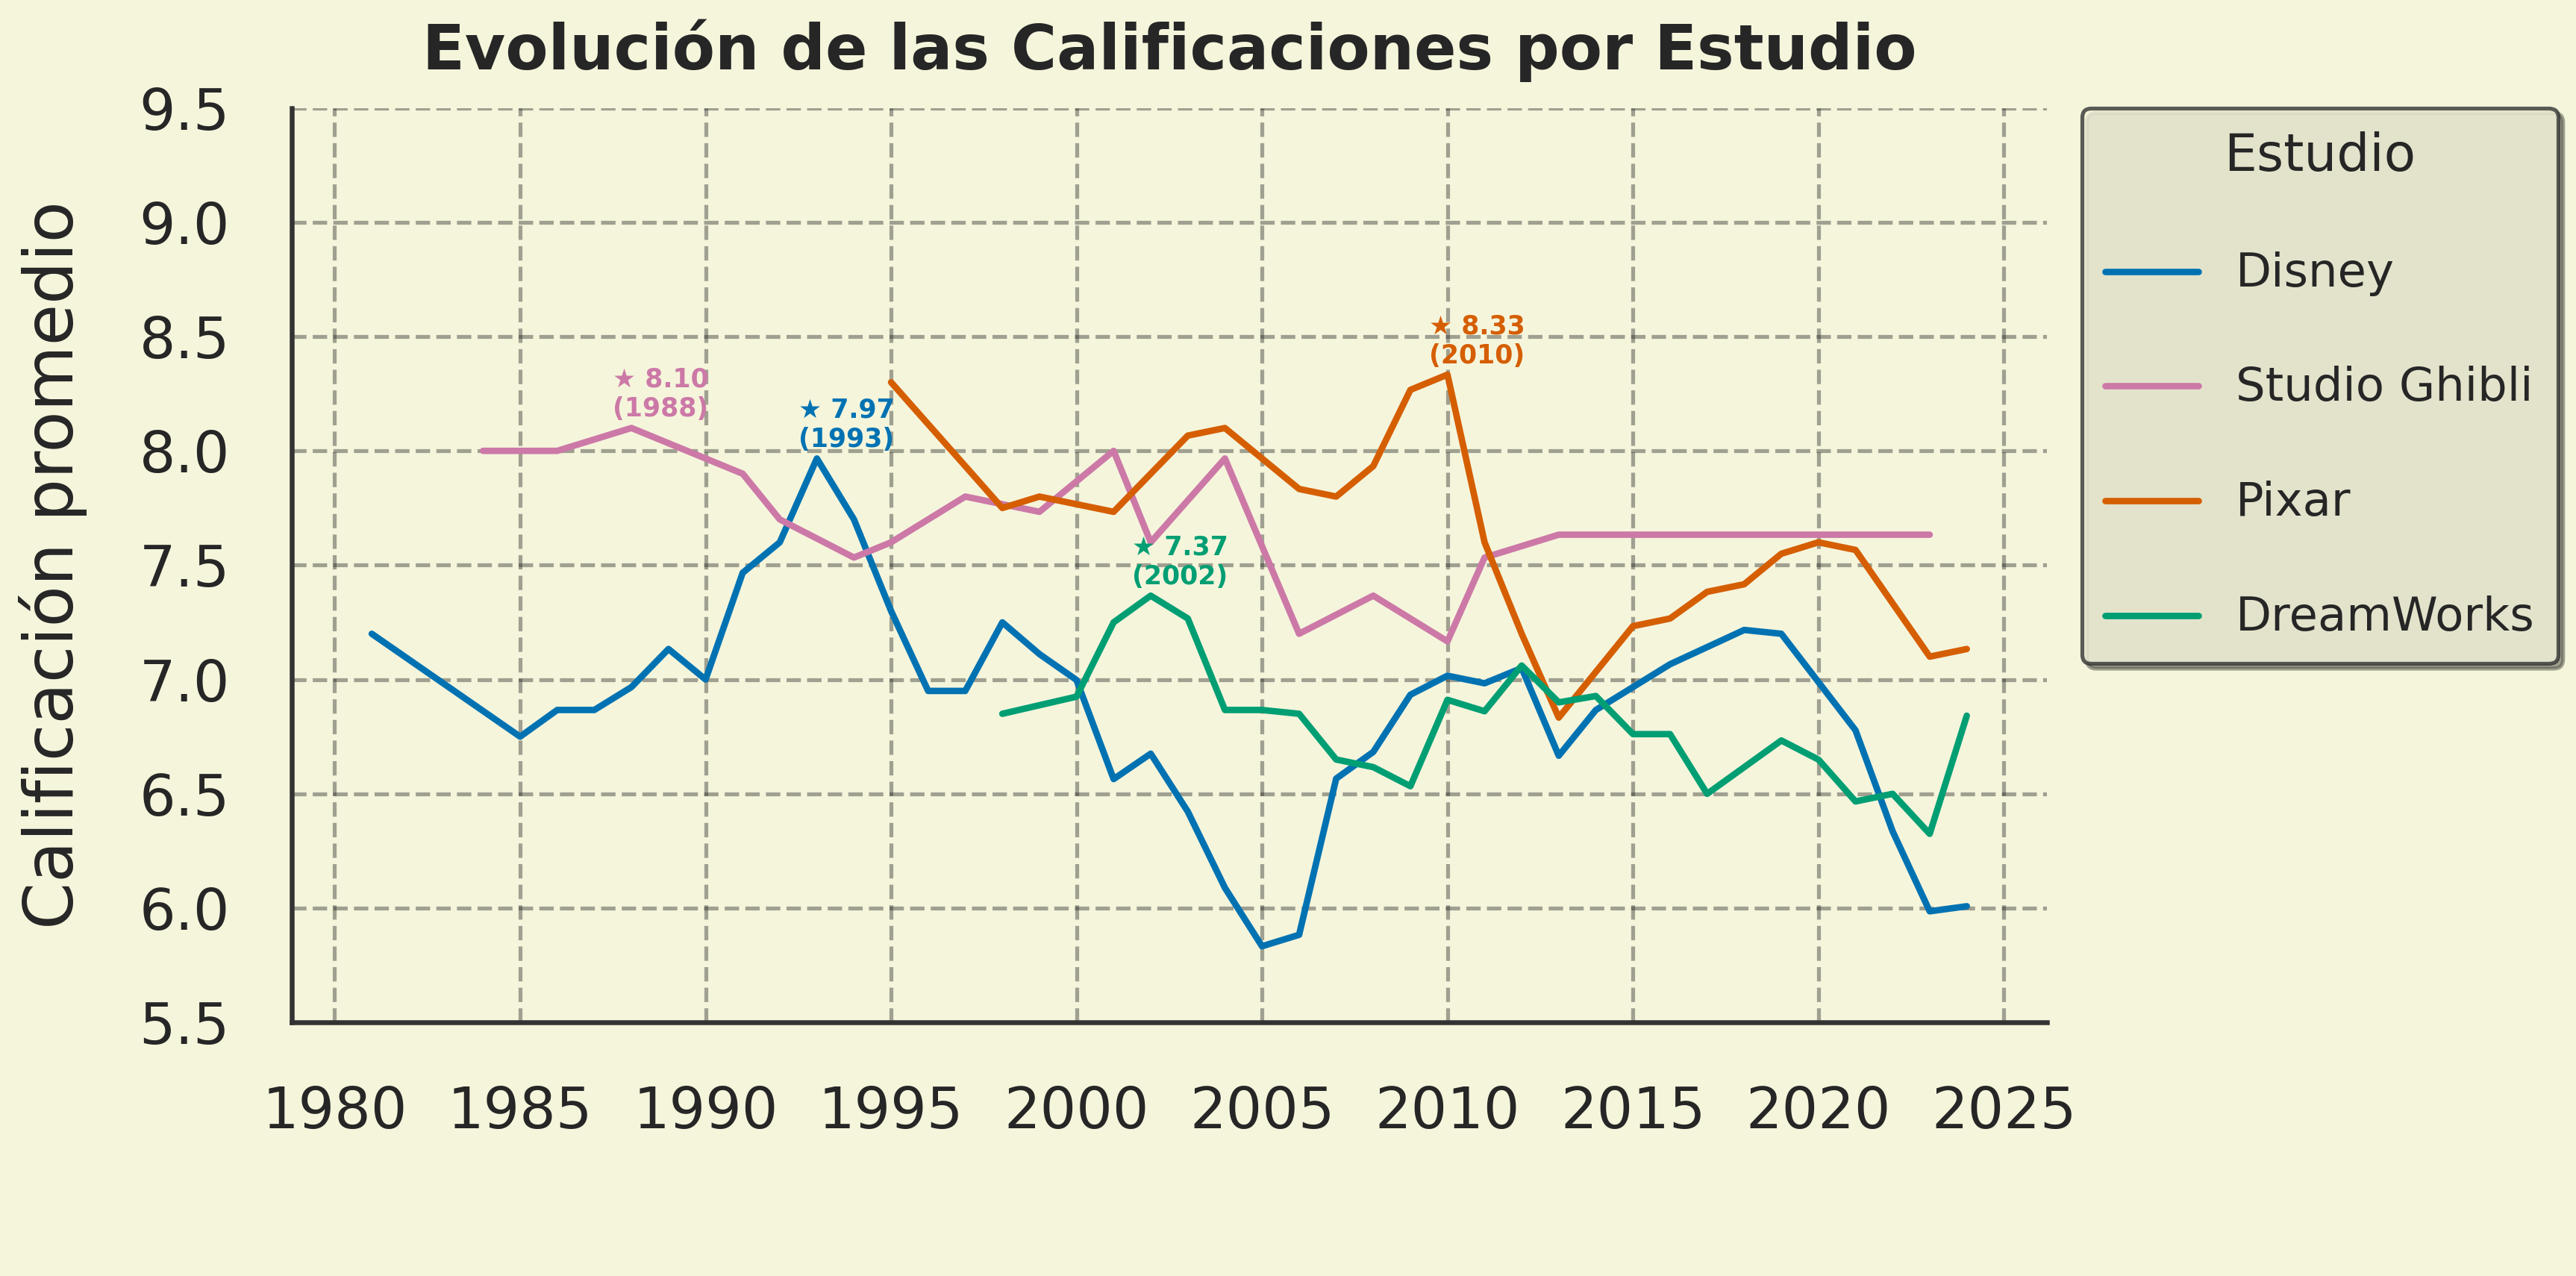

In [10]:
# Cargar años y unir con ratings + estudios
conn = sqlite3.connect("im.db")
years_df = pd.read_sql_query("SELECT tconst, startYear FROM titles WHERE startYear IS NOT NULL", conn)

# Paleta personalizada más contrastante
PALETA_ESTUDIOS = {
    "Disney": "#0072B2",
    "Pixar": "#D55E00",
    "DreamWorks": "#009E73",
    "Studio Ghibli": "#CC79A7"
}

# Crear un DataFrame con los tconst y estudio
def create_company_df(ids, name):
    return pd.DataFrame({"tconst": ids, "studio": name})

all_companies = pd.concat([
    create_company_df(DISNEY, "Disney"),
    create_company_df(PIXAR, "Pixar"),
    create_company_df(DREAMWORKS, "DreamWorks"),
    create_company_df(GHIBLI, "Studio Ghibli")
])

# Cargar datos de la base (título y calificación)
query = """
SELECT tconst, primaryTitle, averageRating
FROM titles
WHERE tconst IN ({seq})
""".format(seq=','.join(['?'] * len(all_companies)))

title_info = pd.read_sql_query(query, conn, params=all_companies['tconst'].tolist())
conn.close()

# Unir con los estudios
merged = pd.merge(title_info, all_companies, on="tconst")

# Eliminar títulos sin rating (por si acaso)
merged = merged.dropna(subset=["averageRating"])

merged_years = pd.merge(merged, years_df, on="tconst")
merged_years["startYear"] = pd.to_numeric(merged_years["startYear"], errors="coerce")
merged_years = merged_years.dropna(subset=["startYear", "averageRating"])
merged_years = merged_years[merged_years["startYear"] >= 1980]

# Calcular promedio por año y estudio
grouped = merged_years.groupby(["startYear", "studio"]).averageRating.mean().reset_index()

# Suavizado por media móvil
grouped["averageSmooth"] = grouped.groupby("studio")["averageRating"].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean())

# Crear figura
plt.figure(figsize=(14, 7))
ax = plt.gca()

# Graficar cada estudio con sombra
for studio in grouped["studio"].unique():
    studio_data = grouped[grouped["studio"] == studio]


    # Línea principal
    sns.lineplot(
        data=studio_data,
        x="startYear",
        y="averageSmooth",
        label=studio,
        color=PALETA_ESTUDIOS[studio],
        linewidth=2.5
    )

        # Anotar el punto más alto
    max_point = studio_data.loc[studio_data["averageSmooth"].idxmax()]
    ax.text(
        max_point["startYear"] - 0.5,
        max_point["averageSmooth"] + 0.05,
        f'★ {max_point["averageSmooth"]:.2f}\n({max_point["startYear"]})',
        color=PALETA_ESTUDIOS[studio],
        weight='bold',
        fontsize=10,
    )


# Ejes
plt.title("Evolución de las Calificaciones por Estudio", pad=15, fontweight='bold',)
plt.xlabel(" ")
plt.ylabel("Calificación promedio")
plt.ylim(5.5, 9.5)

# Eje X con saltos de 5 años
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.tick_params(axis='x')

# Leyenda
plt.legend(title="Estudio", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

C:\Users\cemh0\AppData\Local\Temp\ipykernel_10596\1633207071.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


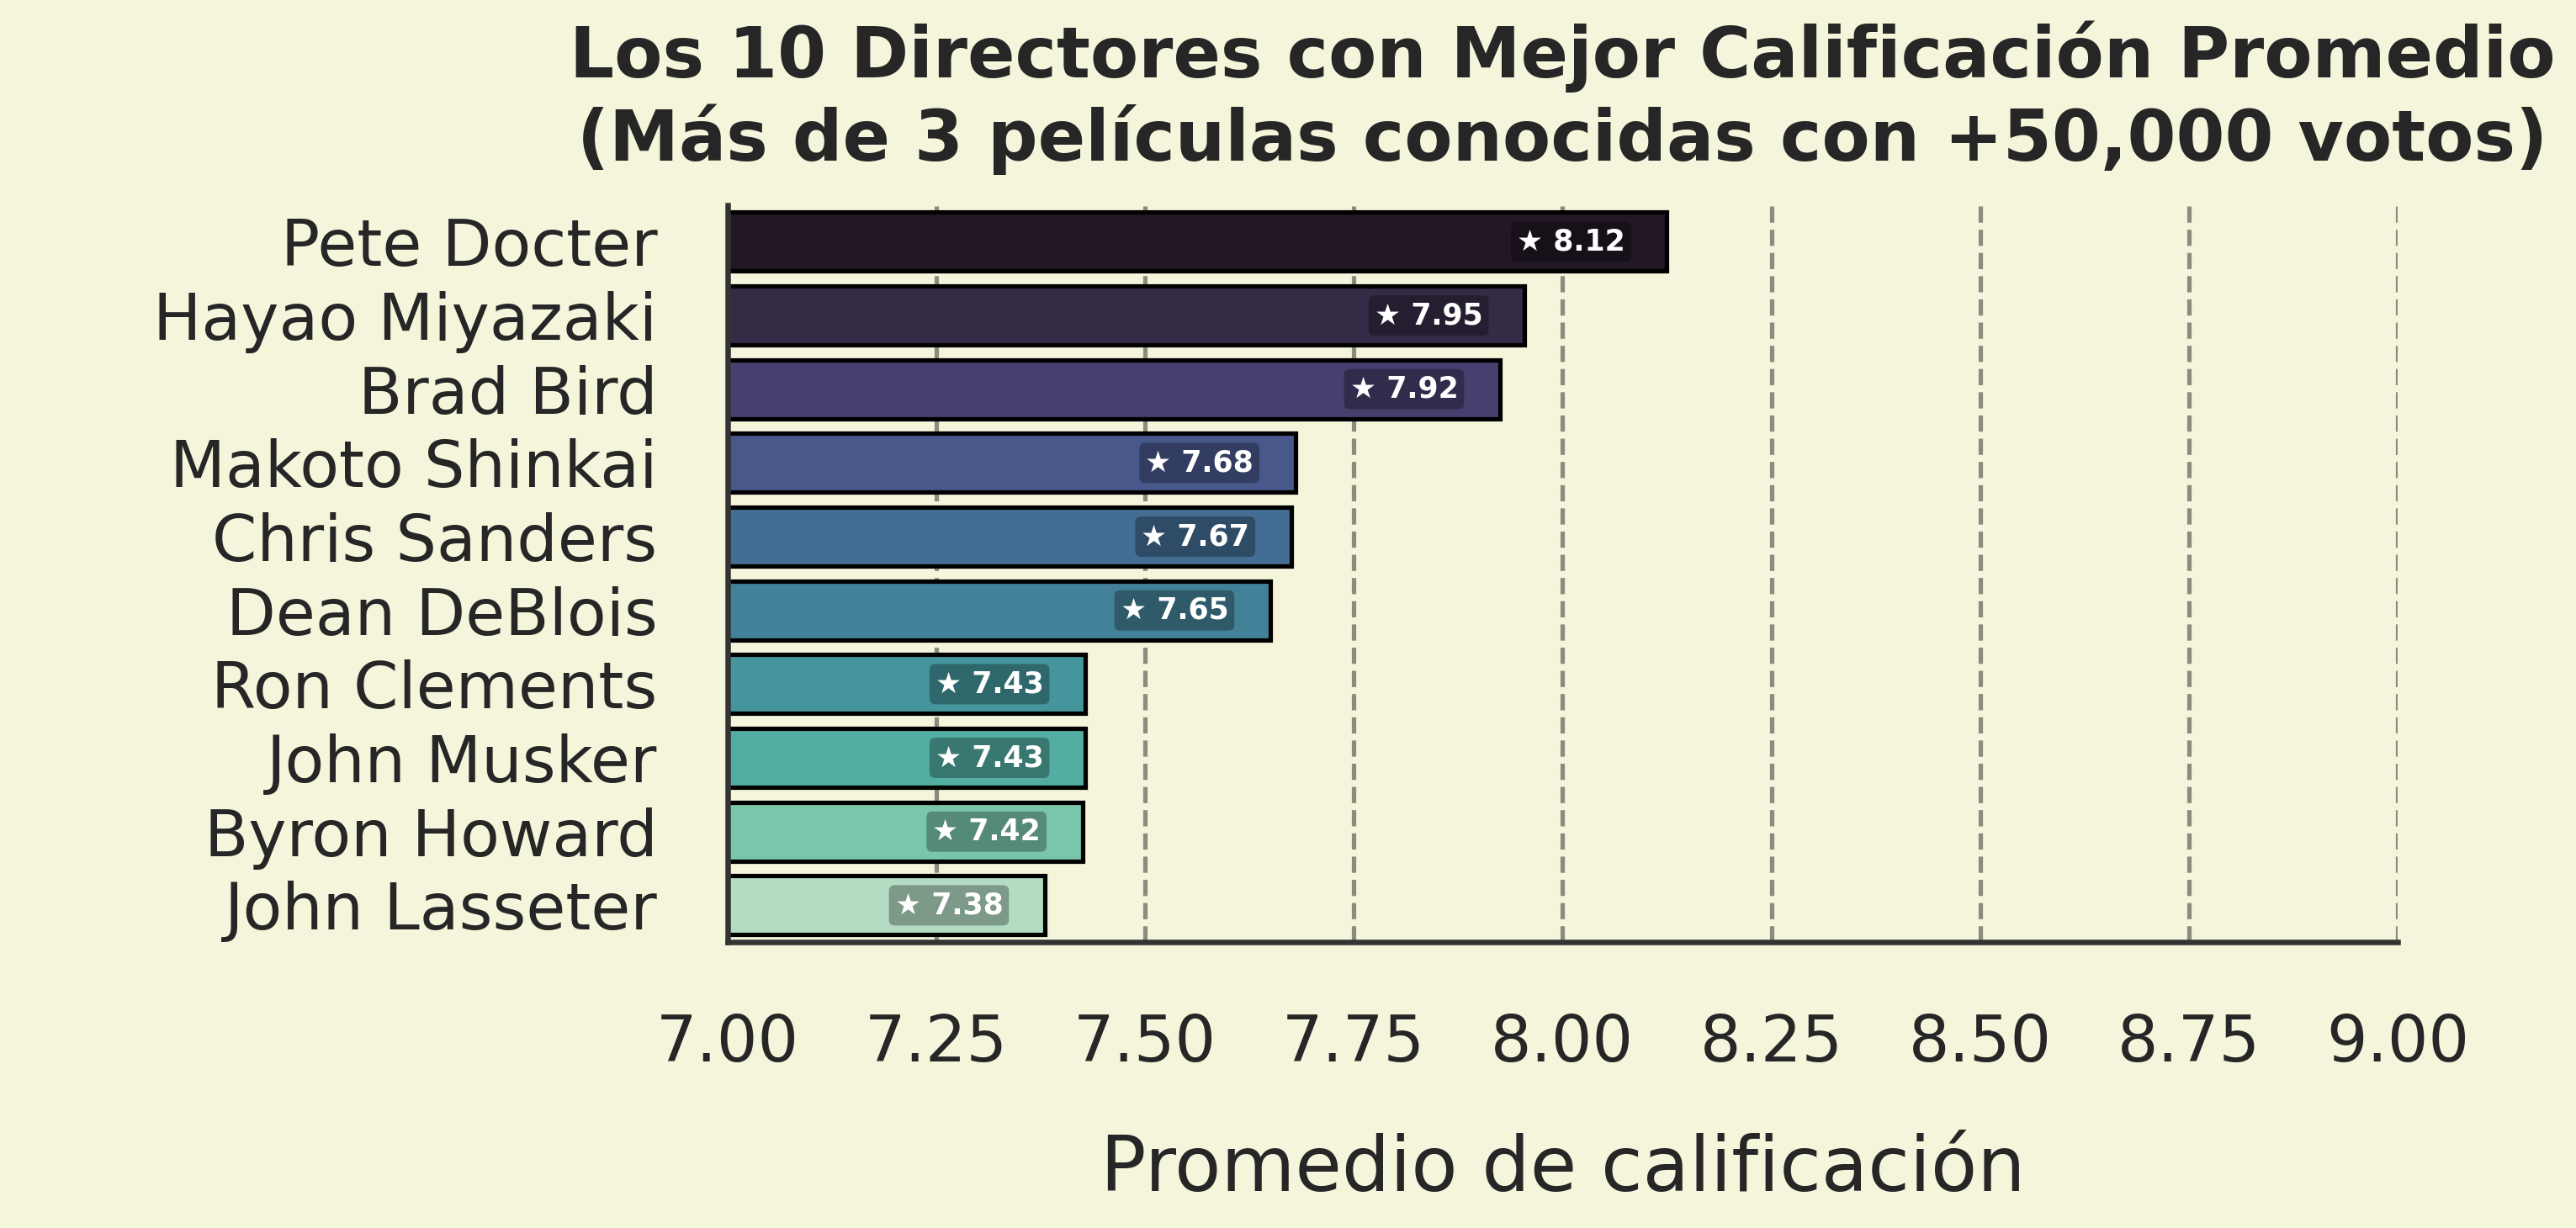

In [11]:
# Conexión a la base de datos
conn = sqlite3.connect("im.db")

# Consulta SQL: películas en known_for, dirigidas por alguien, más de 50,000 votos y promedio
query = """
WITH known_directed AS (
    SELECT DISTINCT k.tconst, r.nconst
    FROM known_for k
    JOIN title_roles r ON k.tconst = r.tconst
    WHERE r.category = 'director'
),
filtered_titles AS (
    SELECT t.tconst, t.primaryTitle, t.averageRating, t.numVotes
    FROM titles t
    WHERE t.averageRating IS NOT NULL AND t.numVotes > 50000
),
combined AS (
    SELECT DISTINCT kd.nconst, p.primaryName, ft.tconst, ft.primaryTitle, ft.averageRating
    FROM known_directed kd
    JOIN filtered_titles ft ON kd.tconst = ft.tconst
    JOIN people p ON kd.nconst = p.nconst
)
SELECT primaryName AS director, COUNT(*) AS num_movies, AVG(averageRating) AS avg_rating
FROM combined
GROUP BY director
HAVING num_movies > 3
ORDER BY avg_rating DESC
LIMIT 10
"""

# Cargar en DataFrame
df = pd.read_sql_query(query, conn)
conn.close()

# Visualización
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df,
    x="avg_rating",
    y="director",
    palette="mako",
    edgecolor="black"
)

plt.title("Los 10 Directores con Mejor Calificación Promedio\n(Más de 3 películas conocidas con +50,000 votos)", fontweight='bold', pad=15)
plt.xlabel("Promedio de calificación")
plt.ylabel(" ")
plt.xlim(7, 9)

# Etiquetas dentro de las barras
for i, row in enumerate(df.itertuples()):
    ax.text(
        row.avg_rating - 0.05,
        i,
        f"★ {row.avg_rating:.2f}",
        ha="right",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", edgecolor="none", facecolor="black", alpha=0.3)
    )
sns.despine()
plt.tight_layout()
plt.show()
